# AdaBoost Algorithm - Code from Scratch


In [332]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions # type: ignore

In [333]:
df = pd.DataFrame()

In [334]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [335]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

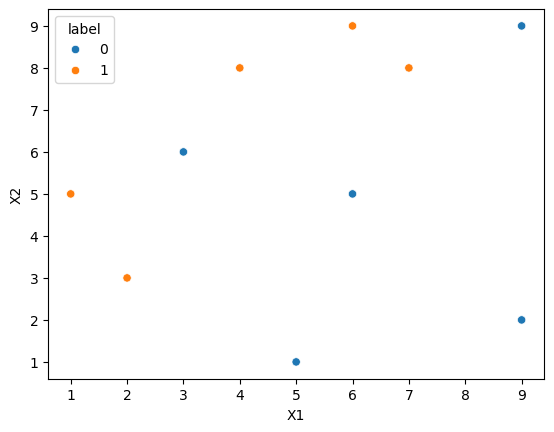

In [336]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [337]:
# assign the weight 
df['weights'] = 1/df.shape[0]

In [338]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [339]:
from sklearn.tree import DecisionTreeClassifier

In [340]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [341]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [342]:
# Step 2 - Train 1st model
dt1.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

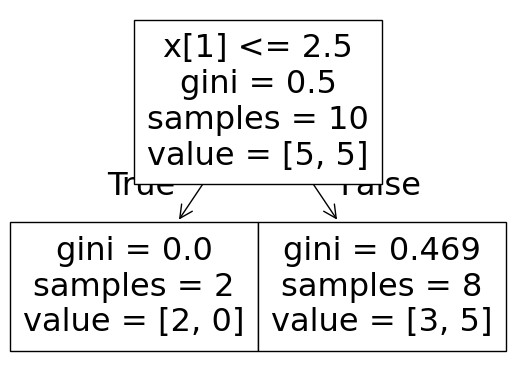

In [343]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

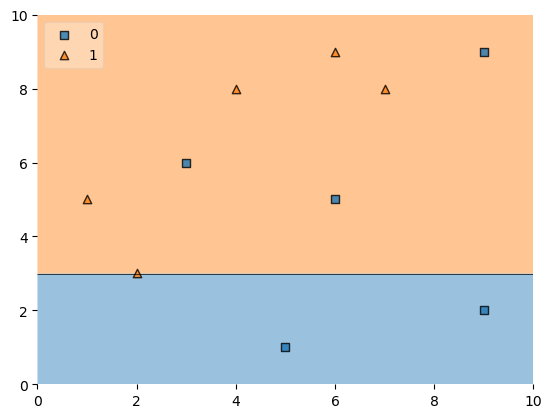

In [344]:
plot_decision_regions(X, y,clf=dt1, legend=2)

In [345]:
df['y_pred'] = dt1.predict(X)

In [346]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [347]:
def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error))

In [348]:
# Step 3 - calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [349]:
# Step 4 - Update weights
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [350]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [351]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [352]:
wt_sum= df['updated_weights'].sum()
wt_sum

np.float64(0.9165153319682015)

In [353]:
df["nomalized_weights"]=df["updated_weights"]/wt_sum

In [354]:
df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [355]:
df['nomalized_weights'].sum()

np.float64(1.0)

In [356]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])

In [357]:
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']

In [358]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [359]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [360]:
index_values = create_new_dataset(df)

index_values

[2, 4, 6, 8, 5, 9, 7, 9, 2, 4]

In [361]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [362]:
second_df

,X1,X2,label,weights
2,3,6,0,0.1
4,5,1,0,0.1
6,6,5,0,0.1
8,9,9,0,0.1
5,6,9,1,0.1
9,9,2,0,0.1
7,7,8,1,0.1
9,9,2,0,0.1
2,3,6,0,0.1
4,5,1,0,0.1


In [363]:
dt2 = DecisionTreeClassifier(max_depth=1)


X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values
dt2.fit(X,y)


,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.625, 0.5, '  False')]

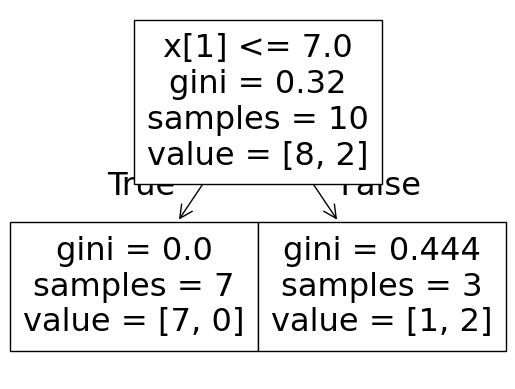

In [364]:
plot_tree(dt2)


<Axes: >

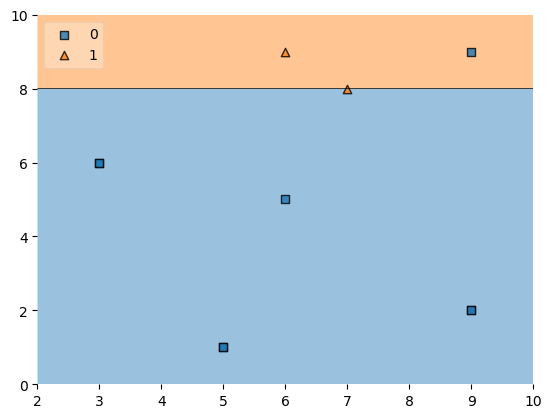

In [365]:
plot_decision_regions(X, y, clf=dt2, legend=2)


In [366]:
second_df['y_pred'] = dt2.predict(X)
second_df

,X1,X2,label,weights,y_pred
2,3,6,0,0.1,0
4,5,1,0,0.1,0
6,6,5,0,0.1,0
8,9,9,0,0.1,1
5,6,9,1,0.1,1
9,9,2,0,0.1,0
7,7,8,1,0.1,1
9,9,2,0,0.1,0
2,3,6,0,0.1,0
4,5,1,0,0.1,0


In [367]:
alpha2 = calculate_model_weight(0.1)
alpha2


np.float64(1.0986122886681098)

In [368]:
# Step 4 - Update weights
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [369]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)
second_df

,X1,X2,label,weights,y_pred,updated_weights
2,3,6,0,0.1,0,0.033622
4,5,1,0,0.1,0,0.033622
6,6,5,0,0.1,0,0.033622
8,9,9,0,0.1,1,0.297427
5,6,9,1,0.1,1,0.033622
9,9,2,0,0.1,0,0.033622
7,7,8,1,0.1,1,0.033622
9,9,2,0,0.1,0,0.033622
2,3,6,0,0.1,0,0.033622
4,5,1,0,0.1,0,0.033622


In [370]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
2,3,6,0,0.1,0,0.033622,0.056034
4,5,1,0,0.1,0,0.033622,0.056034
6,6,5,0,0.1,0,0.033622,0.056034
8,9,9,0,0.1,1,0.297427,0.495694
5,6,9,1,0.1,1,0.033622,0.056034
9,9,2,0,0.1,0,0.033622,0.056034
7,7,8,1,0.1,1,0.033622,0.056034
9,9,2,0,0.1,0,0.033622,0.056034
2,3,6,0,0.1,0,0.033622,0.056034
4,5,1,0,0.1,0,0.033622,0.056034


In [371]:
second_df['nomalized_weights'].sum()


np.float64(0.9999999999999999)

In [372]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']


In [373]:
second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]


,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
2,3,6,0,0.1,0,0.056034,0.000000,0.056034
4,5,1,0,0.1,0,0.056034,0.056034,0.112068
6,6,5,0,0.1,0,0.056034,0.112068,0.168102
8,9,9,0,0.1,1,0.495694,0.168102,0.663796
5,6,9,1,0.1,1,0.056034,0.663796,0.719830
9,9,2,0,0.1,0,0.056034,0.719830,0.775864
7,7,8,1,0.1,1,0.056034,0.775864,0.831898
9,9,2,0,0.1,0,0.056034,0.831898,0.887932
2,3,6,0,0.1,0,0.056034,0.887932,0.943966
4,5,1,0,0.1,0,0.056034,0.943966,1.000000


In [374]:
index_values = create_new_dataset(second_df)


In [375]:
third_df = second_df.iloc[index_values,[0,1,2,3]]
third_df

,X1,X2,label,weights
5,6,9,1,0.1
2,3,6,0,0.1
9,9,2,0,0.1
2,3,6,0,0.1
2,3,6,0,0.1
9,9,2,0,0.1
2,3,6,0,0.1
2,3,6,0,0.1
2,3,6,0,0.1
4,5,1,0,0.1


In [377]:

dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values
dt3.fit(X,y)


,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<Axes: >

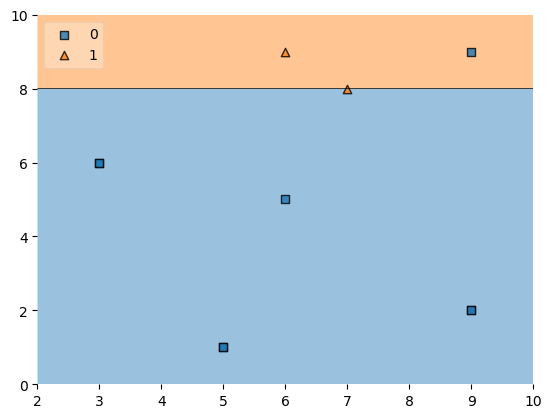

In [378]:
plot_decision_regions(X, y, clf=dt3, legend=2)


In [380]:
third_df['y_pred'] = dt3.predict(X)
third_df

,X1,X2,label,weights,y_pred
5,6,9,1,0.1,0
2,3,6,0,0.1,0
9,9,2,0,0.1,0
2,3,6,0,0.1,1
2,3,6,0,0.1,1
9,9,2,0,0.1,0
2,3,6,0,0.1,1
2,3,6,0,0.1,0
2,3,6,0,0.1,0
4,5,1,0,0.1,0


In [381]:
alpha3 = calculate_model_weight(0.4)
alpha3

np.float64(0.2027325540540821)

In [382]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 0.2027325540540821


## Predection

In [383]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [385]:
dt2.predict(query)


array([0])

In [386]:
dt3.predict(query)


array([0])

In [387]:
alpha1*1 + alpha2*(1) + alpha3*(1)


np.float64(1.7249937729157938)

In [388]:
np.sign(1.7249937729157938)


np.float64(1.0)

In [389]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([1])

In [390]:
dt2.predict(query)


array([1])

In [391]:
dt3.predict(query)


array([1])

In [392]:
alpha1*(1) + alpha2*(-1) + alpha3*(-1)


np.float64(-0.87769591252859)

In [393]:
np.sign(-0.87769591252859)

np.float64(-1.0)